# 16 — Convolutional Neural Networks


**Prerequisite:** notebook 09 (MLP) + notebook 14 (gradient descent / backprop math).
**Theory used:** §6 (bias–variance), §9 (receptive field, parameter sharing).

A Convolutional Neural Network (CNN) is a feed-forward network whose first layers
are **not** fully connected — they *convolve* small learnable filters across the
image. Two ideas fall out for free: **translation invariance** (a cat is a cat
whether it's in the top-left or bottom-right) and **parameter sharing** (the same
edge-detector is useful everywhere). Together they make image recognition tractable:
a CNN beats an MLP of the same image not because it's "deeper" but because its
architecture *bakes in* the structure of images.

This is the first notebook that leaves scikit-learn — `MLPClassifier` can't
convolve. We use **Keras 3 (TensorFlow backend)**. It runs on CPU here, which is
fine: Fashion-MNIST trains in seconds per epoch.

## What you'll be able to do after this notebook

1. Explain **why an MLP is the wrong tool for images** — parameter explosion and the
 loss of spatial structure (§9.1).
2. Describe **convolution** as "slide a small filter, dot-product at each position"
 and **pooling** as "downsample, keep the strongest response".
3. Read a CNN the way you read an MLP: count layers, count **parameters**, predict
 overfitting from the gap between train and validation accuracy.
4. Build, train and diagnose a small **LeNet-style CNN** in Keras.
5. **Visualise what a CNN learns** — filters and feature maps, the "simple → complex
 features" story that is the whole point of the architecture.
6. Know the **modern map**: LeNet → AlexNet → VGG → ResNet, and why almost nobody
 trains from scratch anymore (**transfer learning**).

## The process

```mermaid
flowchart LR
 A["images<br/>28×28"] --> B["conv+ReLU<br/>slide filters"]
 B --> C["pool<br/>halve spatial"]
 C --> D["conv+ReLU<br/>deeper filters"]
 D --> E["pool"]
 E --> F["flatten → dense<br/>MLP on features"]
 F --> G["softmax<br/>10 classes"]
 G --> H["diagnose:<br/>train vs val gap"]
 H -->|overfit| I["+ dropout / aug /<br/>transfer learning"]
 H -->|underfit| J["+ depth / filters /<br/>train longer"]
 style B fill:#dde,stroke:#4c72b0
 style D fill:#dde,stroke:#4c72b0
 style H fill:#fde,stroke:#c44e52
```

The first half (conv → pool → conv → pool) is the **feature extractor**; the second
half (dense → softmax) is a classifier bolted on top — exactly the MLP you already
know from notebook 09. The novelty is entirely in the front.

## 1. Why the MLP breaks on images

Recall the MLP from notebook 09: every input pixel connects to every hidden neuron.
For a `28×28` Fashion-MNIST image that's `784` inputs; a `128`-unit hidden layer
needs `784 × 128 ≈ 100k` weights in its first layer alone. Two problems grow out of
this, and both are fatal for real images.

### 1.1 Parameter explosion with image size

A `224×224` RGB image (the size ImageNet models expect) has `224 × 224 × 3 = 150k`
input values. One `1024`-unit hidden layer needs **150 million weights** — before
you've even added a second layer. You will never collect enough labelled images to
train that many free parameters without massive overfitting (§6).

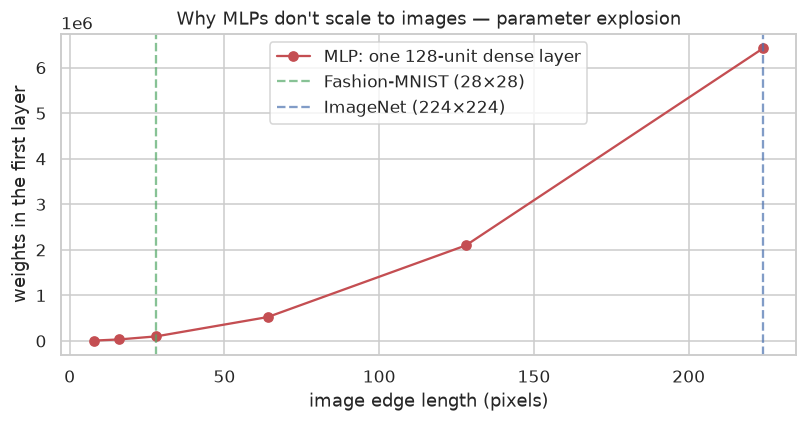

In [1]:
from setup import *
import os
# Silence TF's C++ log + oneDNN info lines. Must run before `import tensorflow`.
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
import tensorflow as tf
from tensorflow import keras

# Parameter count of a single dense layer, as a function of image edge length.
edge = np.array([8, 16, 28, 64, 128, 224]) # image edge in pixels
pixels = edge ** 2
dense_params = pixels * 128 # one hidden layer of 128 units

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(edge, dense_params, "o-", color="#c44e52", label="MLP: one 128-unit dense layer")
ax.set_xlabel("image edge length (pixels)")
ax.set_ylabel("weights in the first layer")
ax.set_title("Why MLPs don't scale to images — parameter explosion")
ax.axvline(28, color="#55a868", ls="--", alpha=0.7, label="Fashion-MNIST (28×28)")
ax.axvline(224, color="#4c72b0", ls="--", alpha=0.7, label="ImageNet (224×224)")
ax.legend()
plt.tight_layout(); plt.show()

The curve is a parabola: double the image width and your parameter count quadruples.
A CNN sidesteps this with **parameter sharing** — instead of one weight per pixel,
you learn a small `3×3` filter (9 weights) and reuse it across the whole image.

### 1.2 Spatial structure is destroyed by flattening

An MLP flattens the image into a `784`-vector the moment it sees it. That throws away
the fact that neighbouring pixels form edges, edges form corners, corners form
objects. Two pixels far apart in the flattened vector might be right next to each
other in the image. The MLP *can* in principle learn the right thing, but it has to
**rediscover spatial locality from scratch** for every image size — and it has to
learn that "a shirt in the top-left" and "a shirt in the bottom-right" are the same
object. A CNN gets both for free from the convolution operation.

## 2. The convolution operation, by hand

**Convolution** in a CNN is simply this: take a small matrix of learnable weights
(the **filter** or **kernel**), slide it across the image one pixel at a time
(the **stride**), and at each position compute the dot product of the filter with
the patch of image under it. The output is a new image-like array called a
**feature map** — bright where the filter "matched" the image, dark where it didn't.

A `3×3` filter has 9 weights, *regardless of image size*. That's parameter sharing.
And the same filter visits every location — that's translation invariance: if the
pattern it detects appears anywhere, the same strong response fires.

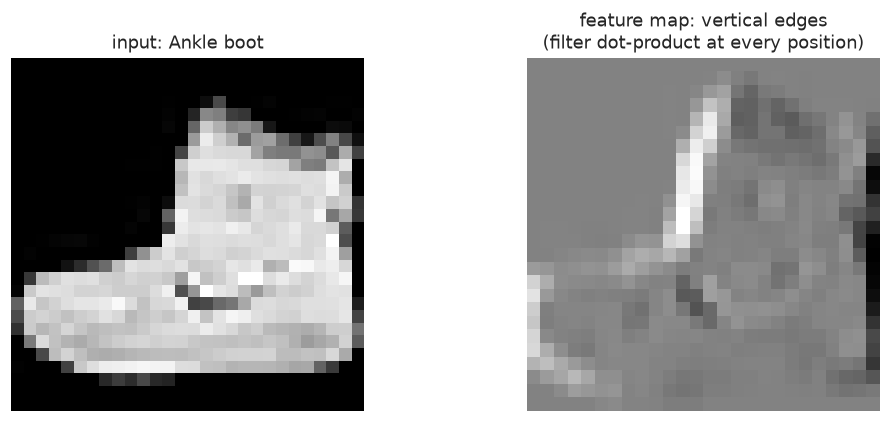

filter shape (3, 3) -> 9 weights, reused across all 784 pixels.


In [2]:
# Load one Fashion-MNIST image to play with.
(x_train, y_train), _ = keras.datasets.fashion_mnist.load_data()
img = x_train[0].astype("float32") / 255.0 # a shoe, 28×28
labels = ["T-shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt",
 "Sneaker","Bag","Ankle boot"]

# Convolve by hand with a fixed filter so you can see what "sliding" produces.
def convolve2d(image, kernel):
    # Plain convolution, stride 1, no padding. image: (H,W), kernel: (k,k).
    k = kernel.shape[0]
    out_h, out_w = image.shape[0] - k + 1, image.shape[1] - k + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i, j] = np.sum(image[i:i+k, j:j+k] * kernel)
    return out

# A classic hand-designed edge detector (Sobel) — CNNs learn these themselves.
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype="float32")
edge_map = convolve2d(img, sobel_x)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img, cmap="gray"); axes[0].set_title(f"input: {labels[y_train[0]]}")
axes[1].imshow(edge_map, cmap="gray"); axes[1].set_title("feature map: vertical edges\n(filter dot-product at every position)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
print(f"filter shape {sobel_x.shape} -> 9 weights, reused across all {28*28} pixels.")

The right-hand image is literally the output of sliding a `3×3` filter across the
left-hand image and computing one dot product per position. Bright bands = vertical
edges in the shoe. A CNN *learns* a bank of these filters from data instead of us
hand-designing them — but the operation is exactly what you just saw.

> **Vocabulary (§9.2).** A **filter/kernel** is the small weight matrix.
> The **feature map** is its output. The **stride** is how many pixels it jumps per
> step. **Padding** adds zeros around the border so the output keeps the input's
> spatial size (`"same"` padding) instead of shrinking (`"valid"` padding).

## 3. The full CNN stack: conv → pool → dense

A real CNN layers several of these operations. A typical block is:

$$\underbrace{\text{conv} \to \text{ReLU}}_{\text{detect features}}
\quad\to\quad
\underbrace{\text{pool}}_{\text{summarise / shrink}}
\quad\to\quad \dots \quad\to\quad
\underbrace{\text{flatten} \to \text{dense} \to \text{softmax}}_{\text{classify}}$$

**Pooling** (usually `2×2 max-pooling`) takes each `2×2` patch and keeps only its
largest value, halving both spatial dimensions. Two effects: it shrinks the feature
maps (cheaper, fewer parameters downstream) and it adds **translation robustness**
— a feature detected one pixel over still survives pooling. Pooling has **no
learnable parameters** at all.

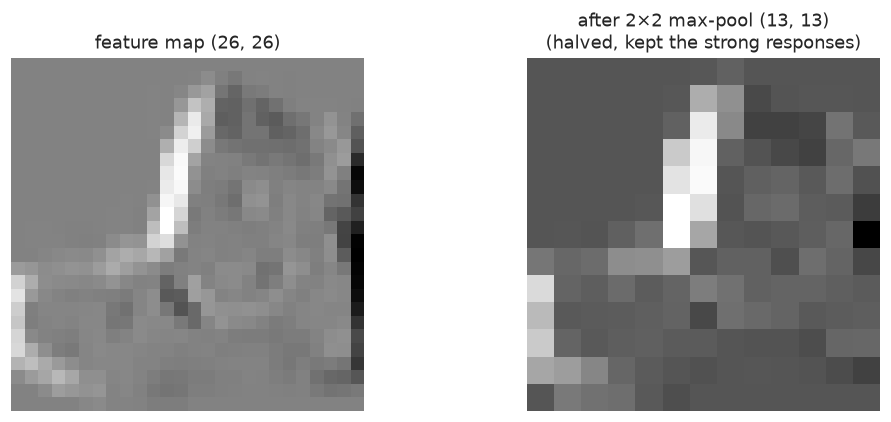

In [3]:
# Demonstrate max-pooling on the edge map above — halves the size, keeps peaks.
def maxpool2x2(image):
 h, w = image.shape
 h2, w2 = h - h % 2, w - w % 2
 image = image[:h2, :w2].reshape(h2 // 2, 2, w2 // 2, 2)
 return image.max(axis=(1, 3))

pooled = maxpool2x2(edge_map)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(edge_map, cmap="gray"); axes[0].set_title(f"feature map {edge_map.shape}")
axes[1].imshow(pooled, cmap="gray"); axes[1].set_title(f"after 2×2 max-pool {pooled.shape}\n(halved, kept the strong responses)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

### 3.1 How the spatial dimensions shrink through the stack

The shape transforms are the thing to internalise. For a `28×28` input with two
conv-pool blocks:

| Layer | Operation | Output shape | Notes |
|---|---|---|---|
| input | — | `28 × 28 × 1` | grayscale, 1 channel |
| conv1 | `3×3`, 8 filters | `26 × 26 × 8` | `"valid"` pad shrinks edge by 2 |
| pool1 | `2×2` max | `13 × 13 × 8` | halve spatial, channels unchanged |
| conv2 | `3×3`, 16 filters | `11 × 11 × 16` | more filters, deeper features |
| pool2 | `2×2` max | `5 × 5 × 16` | |
| flatten | — | `400` | `5×5×16` collapsed to a vector |
| dense | 64 units | `64` | back in MLP territory |
| softmax | 10 | `10` | class probabilities |

Two patterns: **spatial dimensions shrink** (28→13→5) while **channel count grows**
(1→8→16). Early layers detect simple local features in few channels; deeper layers
combine them into richer features in more channels. By the time we flatten, the
spatial information has been compressed into a rich feature vector.

## 4. Build and train a LeNet-style CNN

We'll build exactly the stack from §3.1 and train it on Fashion-MNIST. This is the
same family of model Yann LeCun used on digits in 1998 (LeNet-5) — it's small enough
to train on CPU in seconds per epoch and large enough to handily beat the MLP.

In [4]:
# Load Fashion-MNIST and prepare it. Keras gives us 60k train / 10k test, 28×28 grayscale.
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
# CNNs expect a channel axis: (28,28) -> (28,28,1)
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]
print(f"train {x_train.shape}, test {x_test.shape}, {len(labels)} classes")

# Hold out 10% of train as a validation set so we can watch for overfitting.
from sklearn.model_selection import train_test_split
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1,
 stratify=y_train, random_state=42)
print(f"train {x_tr.shape}, val {x_val.shape}")

train (60000, 28, 28, 1), test (10000, 28, 28, 1), 10 classes
train (54000, 28, 28, 1), val (6000, 28, 28, 1)


In [5]:
# Build the LeNet-style CNN from the §3.1 table.
keras.utils.set_random_seed(42)
cnn = keras.Sequential([
 keras.layers.Input(shape=(28, 28, 1)),
 keras.layers.Conv2D(8, 3, activation="relu", name="conv1"),
 keras.layers.MaxPooling2D(2, name="pool1"),
 keras.layers.Conv2D(16, 3, activation="relu", name="conv2"),
 keras.layers.MaxPooling2D(2, name="pool2"),
 keras.layers.Flatten(name="flatten"),
 keras.layers.Dense(64, activation="relu", name="dense"),
 keras.layers.Dense(10, activation="softmax", name="out"),
], name="lenet_fashion")
cnn.compile(optimizer="adam",
 loss="sparse_categorical_crossentropy",
 metrics=["accuracy"])
cnn.summary()

Model: "lenet_fashion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,562 (107.66 KB)

 Trainable params: 27,562 (107.66 KB)

 Non-trainable params: 0 (0.00 B)

Read `model.summary()` carefully — it's the CNN equivalent of reading a DataFrame's
`.info()`. Two columns matter:

- **Param #** — how many learnable weights each layer contributes. The conv layers
 have *far* fewer than you might expect: `conv1` has `8 × (3×3×1) + 8 = 80` weights
 (8 filters, each `3×3×1`, plus 1 bias per filter). Compare that to the `784×128`
 dense layer an MLP would need. This is parameter sharing made concrete.
- **Output shape** — tracks the spatial-shrinking / channel-growing pattern from §3.1.

In [6]:
# Train for a few epochs and capture the history so we can plot learning curves.
hist = cnn.fit(x_tr, y_tr, validation_data=(x_val, y_val),
 epochs=8, batch_size=128, verbose=0)
hist_df = pd.DataFrame(hist.history)
hist_df.index.name = "epoch"
print(hist_df.round(3))

       accuracy   loss  val_accuracy  val_loss
epoch                                         
0         0.738  0.727         0.829     0.478
1         0.834  0.458         0.853     0.413
2         0.851  0.410         0.867     0.377
3         0.863  0.379         0.877     0.349
4         0.870  0.357         0.882     0.332
5         0.876  0.340         0.883     0.322
6         0.880  0.327         0.886     0.315
7         0.884  0.315         0.889     0.307


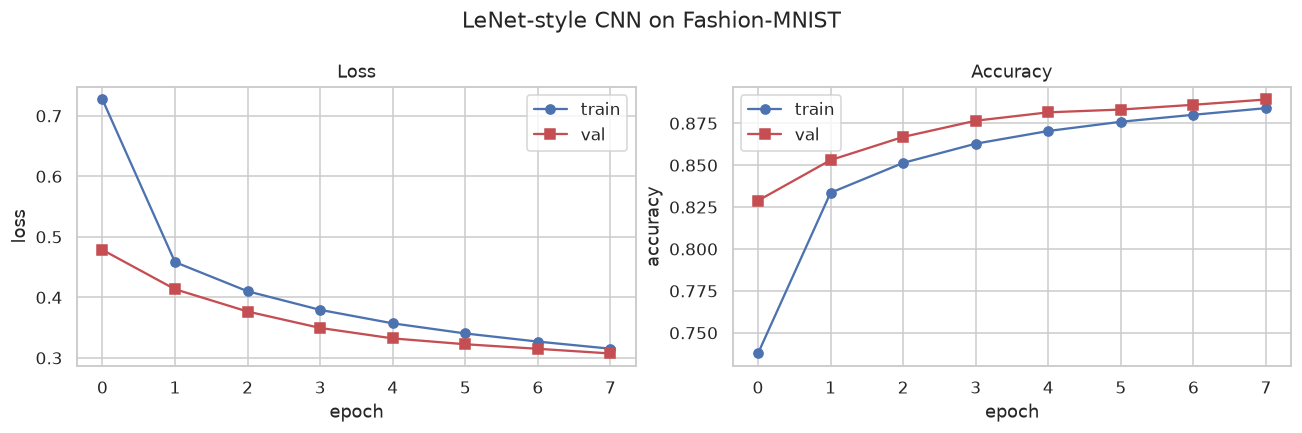


Test accuracy: 0.874 (baseline = guessing = 0.10)


In [7]:
# The diagnostic plot — always look at train vs val together (§6.2).
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist.history["loss"], "o-", color="#4c72b0", label="train")
axes[0].plot(hist.history["val_loss"], "s-", color="#c44e52", label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss")
axes[1].plot(hist.history["accuracy"], "o-", color="#4c72b0", label="train")
axes[1].plot(hist.history["val_accuracy"], "s-", color="#c44e52", label="val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy")
for ax in axes: ax.legend()
plt.suptitle("LeNet-style CNN on Fashion-MNIST"); plt.tight_layout(); plt.show()

test_acc = cnn.evaluate(x_test, y_test, verbose=0)[1]
print(f"\nTest accuracy: {test_acc:.3f} (baseline = guessing = 0.10)")

## 5. Failure case A — the MLP contrast (why we bothered with convolution)

The clearest way to *see* the CNN's advantage is to train an MLP of comparable
budget on the same data and watch it lose. Same dataset, same training loop, only
the architecture changes. This is the contrast case the syllabus asks for.

In [8]:
# An MLP that flattens the image to a 784-vector first.
keras.utils.set_random_seed(42)
mlp = keras.Sequential([
 keras.layers.Input(shape=(28, 28, 1)),
 keras.layers.Flatten(),
 keras.layers.Dense(128, activation="relu"),
 keras.layers.Dense(64, activation="relu"),
 keras.layers.Dense(10, activation="softmax"),
], name="mlp_fashion")
mlp.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

mlp_params = mlp.count_params()
cnn_params = cnn.count_params()
print(f"MLP params: {mlp_params:,} CNN params: {cnn_params:,}")

hist_mlp = mlp.fit(x_tr, y_tr, validation_data=(x_val, y_val),
 epochs=8, batch_size=128, verbose=0)
mlp_test = mlp.evaluate(x_test, y_test, verbose=0)[1]

MLP params: 109,386 CNN params: 27,562


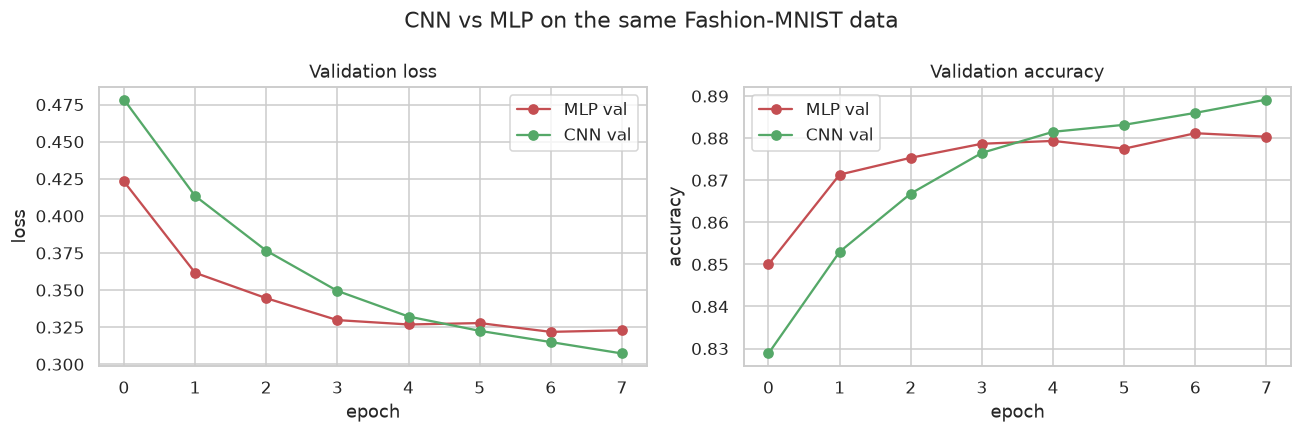

MLP test acc 0.866 CNN test acc 0.874
MLP params 109,386 CNN params 27,562 (CNN uses fewer and does better)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, h, color in [("MLP", hist_mlp.history, "#c44e52"),
 ("CNN", hist.history, "#55a868")]:
 axes[0].plot(h["val_loss"], "o-", color=color, label=f"{name} val")
 axes[1].plot(h["val_accuracy"], "o-", color=color, label=f"{name} val")
axes[0].set_title("Validation loss"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[1].set_title("Validation accuracy"); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
for ax in axes: ax.legend()
plt.suptitle("CNN vs MLP on the same Fashion-MNIST data"); plt.tight_layout(); plt.show()
print(f"MLP test acc {mlp_test:.3f} CNN test acc {test_acc:.3f}")
print(f"MLP params {mlp_params:,} CNN params {cnn_params:,} (CNN uses fewer and does better)")

**The pattern:** the CNN reaches higher validation accuracy with *fewer* parameters.
That gap is the whole argument for convolution: by baking spatial structure into the
architecture, you spend your parameter budget on things that generalise (edges,
textures, part-whole relationships) instead of wasting it re-learning "pixel 142 is
next to pixel 143" from scratch every epoch.

> **Rule of thumb:** if your input has spatial (images) or sequential (text/audio)
> structure, reach for the architecture that respects it (CNN / RNN / Transformer).
> Flatten-and-dense is a baseline, not a destination.

## 6. Failure case B — overfitting without regularisation

CNNs are powerful, and powerful models overfit. The signature is a growing gap
between training accuracy (sails toward 1.0) and validation accuracy (stalls). Let's
train a bigger CNN with no regularisation for longer to provoke it deliberately —
then fix it with **dropout + data augmentation** (§6.2).

In [10]:
# A deliberately over-capacity CNN, no dropout, no augmentation.
keras.utils.set_random_seed(42)
big = keras.Sequential([
 keras.layers.Input(shape=(28, 28, 1)),
 keras.layers.Conv2D(64, 3, activation="relu"),
 keras.layers.MaxPooling2D(2),
 keras.layers.Conv2D(128, 3, activation="relu"),
 keras.layers.MaxPooling2D(2),
 keras.layers.Flatten(),
 keras.layers.Dense(256, activation="relu"),
 keras.layers.Dense(10, activation="softmax"),
], name="big_overfit")
big.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_big = big.fit(x_tr, y_tr, validation_data=(x_val, y_val),
 epochs=8, batch_size=128, verbose=0)

In [11]:
# Same architecture + dropout(0.5) on the dense layer + light augmentation.
data_aug = keras.Sequential([
 keras.layers.RandomZoom(0.1), keras.layers.RandomTranslation(0.1, 0.1),
], name="aug")
keras.utils.set_random_seed(42)
reg = keras.Sequential([
 keras.layers.Input(shape=(28, 28, 1)),
 data_aug,
 keras.layers.Conv2D(64, 3, activation="relu"),
 keras.layers.MaxPooling2D(2),
 keras.layers.Conv2D(128, 3, activation="relu"),
 keras.layers.MaxPooling2D(2),
 keras.layers.Flatten(),
 keras.layers.Dropout(0.5),
 keras.layers.Dense(256, activation="relu"),
 keras.layers.Dropout(0.5),
 keras.layers.Dense(10, activation="softmax"),
], name="big_regularised")
reg.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_reg = reg.fit(x_tr, y_tr, validation_data=(x_val, y_val),
 epochs=8, batch_size=128, verbose=0)

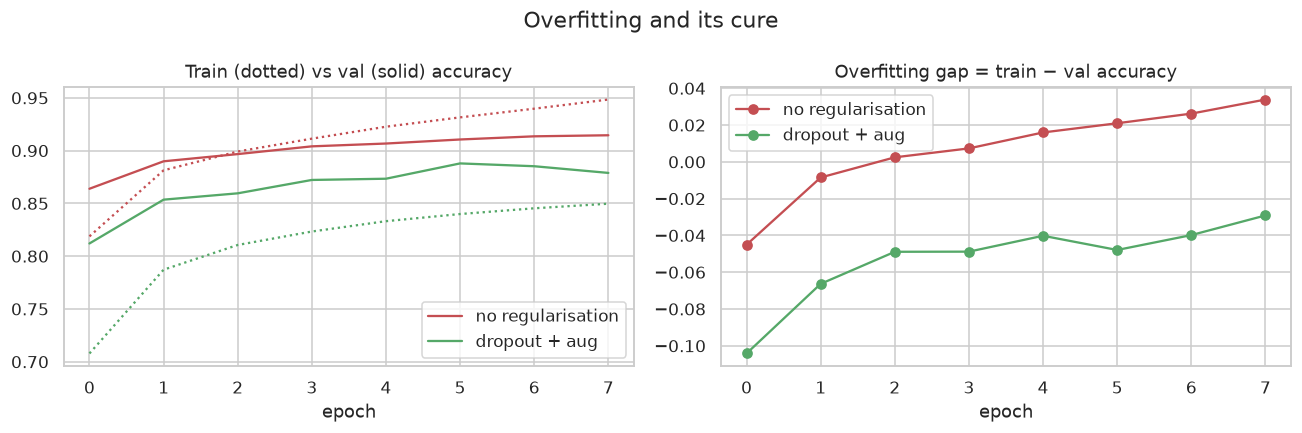

In [12]:
# Plot the train/val gap for both — the gap IS the overfitting.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, h, color in [("no regularisation", hist_big.history, "#c44e52"),
 ("dropout + aug", hist_reg.history, "#55a868")]:
 gap = np.array(h["accuracy"]) - np.array(h["val_accuracy"])
 axes[0].plot(h["accuracy"], ":", color=color) # train (dotted)
 axes[0].plot(h["val_accuracy"], "-", color=color, label=name) # val (solid)
 axes[1].plot(gap, "o-", color=color, label=name)
axes[0].set_title("Train (dotted) vs val (solid) accuracy")
axes[1].set_title("Overfitting gap = train − val accuracy")
for ax in axes: ax.set_xlabel("epoch"); ax.legend()
plt.suptitle("Overfitting and its cure"); plt.tight_layout(); plt.show()

**Reading the curves:** the red gap balloons — training accuracy climbs toward
`0.99` while validation plateaus around `0.91`. That widening gap *is* overfitting:
the model is memorising training quirks that don't generalise. The green curves
(dropout + augmentation) keep train and val much closer; validation ends higher
because the model was forced to learn robust features.

> **Three levers against CNN overfitting (§6.2):**
> 1. **Data augmentation** — the single best regulariser for images. Randomly
> shift / zoom / rotate the training images so the model sees variety.
> 2. **Dropout** — zero out a random fraction of activations each step (notebook 15 §5).
> 3. **Early stopping** — halt when validation loss stops improving.
> Add them in roughly that order of payoff.

## 7. Visualising what the CNN learned

The most useful diagnostic (and the most satisfying thing about CNNs): you can
*look* at the filters and feature maps and see what each layer detects. This is the
"simple → complex features" story from Lecture 7 made literal — early layers
find edges and textures; deeper layers combine them into part-detectors.

conv1 filters: (3, 3, 1, 8) (8 filters, 3×3 spatial, 1 input channel)


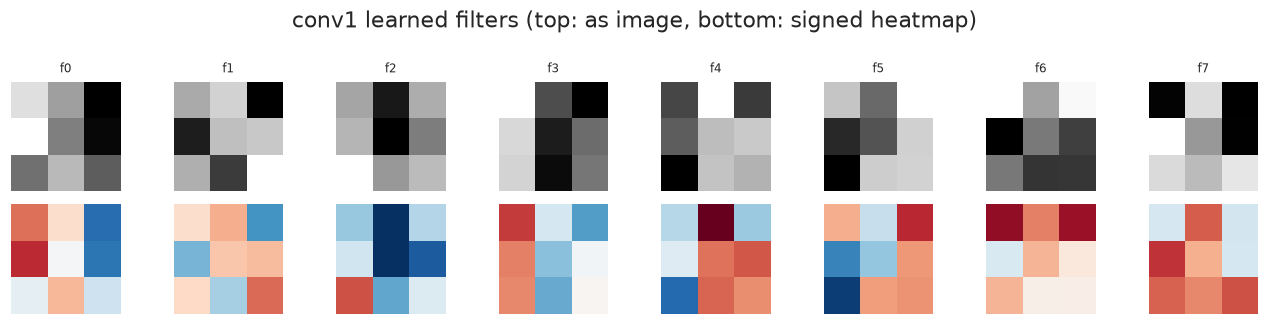

In [13]:
# Grab the filters learned by conv1 (8 filters, each 3×3×1).
w, b = cnn.get_layer("conv1").get_weights()
print(f"conv1 filters: {w.shape} (8 filters, 3×3 spatial, 1 input channel)")

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
 axes[0, i].imshow(w[:, :, 0, i], cmap="gray"); axes[0, i].set_title(f"f{i}", fontsize=8); axes[0, i].axis("off")
 axes[1, i].imshow(w[:, :, 0, i], cmap="RdBu_r", vmin=-w.max(), vmax=w.max()); axes[1, i].axis("off")
axes[0, 0].set_ylabel("weights", fontsize=8)
plt.suptitle("conv1 learned filters (top: as image, bottom: signed heatmap)"); plt.tight_layout(); plt.show()

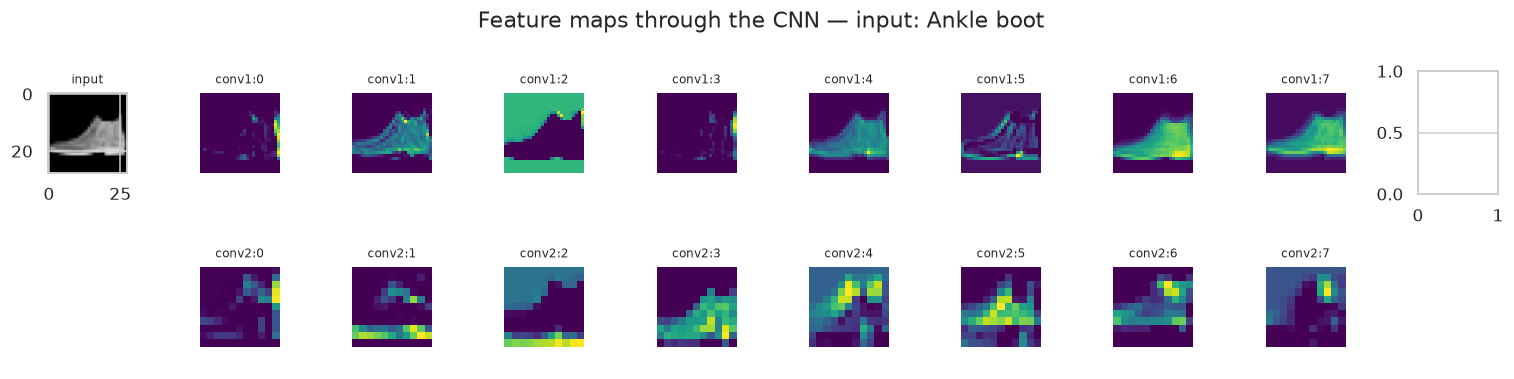

In [14]:
# Now pass one image through and look at the ACTIVATIONS at each layer.
sample = x_test[0:1] # one ankle-boot, keep batch dim
feat_model = keras.Model(inputs=cnn.inputs,
 outputs=[l.output for l in cnn.layers if "conv" in l.name])
maps = feat_model.predict(sample, verbose=0)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
axes[0, 0].imshow(sample[0, :, :, 0], cmap="gray"); axes[0, 0].set_title("input", fontsize=8)
axes[1, 0].axis("off")
for j in range(8):
 axes[0, j+1].imshow(maps[0][0, :, :, j], cmap="viridis"); axes[0, j+1].set_title(f"conv1:{j}", fontsize=8)
 axes[0, j+1].axis("off")
for j in range(min(8, maps[1].shape[-1])):
 axes[1, j+1].imshow(maps[1][0, :, :, j], cmap="viridis"); axes[1, j+1].set_title(f"conv2:{j}", fontsize=8)
 axes[1, j+1].axis("off")
for j in range(8, 10): axes[1, j].axis("off")
plt.suptitle(f"Feature maps through the CNN — input: {labels[y_test[0]]}"); plt.tight_layout(); plt.show()

Notice how `conv1` maps look like the input filtered for edges and blobs (low-level
texture), while `conv2` maps are sparser and more abstract — they light up at
specific part-locations (the sole, the heel). Each layer is recomposing the previous
layer's features into higher-level ones. By the dense layer the network is working
with a compact code of "shoe-ness", not pixels.

## 8. The modern map: LeNet → AlexNet → VGG → ResNet → transfer learning

You should recognise the names even if you never implement them. Each solved a
bottleneck of its predecessor:

| Year | Net | Key idea | Depth | Why it mattered |
|---|---|---|---|---|
| 1998 | **LeNet-5** | conv+pool stack, end-to-end trained | ~7 | proved CNNs work on digits |
| 2012 | **AlexNet** | GPU training + ReLU + dropout | 8 | won ImageNet by a huge margin, started the DL era |
| 2014 | **VGG** | stack of `3×3` convs, uniform design | 16–19 | showed depth + small filters beats few big ones |
| 2015 | **ResNet** | **skip connections** let gradients flow | 50–152 | made very deep nets trainable (§9.3) |
| 2018+ | **EfficientNet / ViT** | architecture search / transformers | — | CNNs no longer the only game in town |

### Why almost nobody trains from scratch

A ResNet trained on ImageNet has already learned, in its early layers, an
exceptionally useful general-purpose visual vocabulary (edges → textures → parts).
For your own image task you take that pre-trained network and **fine-tune** only the
last few layers on your data — **transfer learning**. It needs far less data and
trains in minutes. Keras ships these pre-trained models ready to use:

In [15]:
# Transfer learning in ~6 lines. We don't run a full training (CIFAR is too small
# for a real ResNet) — this just shows the pattern you'll reuse on real images.
# (Uncomment the fit() to actually fine-tune.)
keras.utils.set_random_seed(42)
base = keras.applications.MobileNetV2(weights="imagenet", include_top=False,
 input_shape=(96, 96, 3))
base.trainable = False # freeze the pre-trained feature extractor

transfer = keras.Sequential([
 keras.layers.Input(shape=(96, 96, 3)),
 base,
 keras.layers.GlobalAveragePooling2D(),
 keras.layers.Dropout(0.3),
 keras.layers.Dense(10, activation="softmax"),
], name="transfer_demo")
transfer.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print(f"Pre-trained backbone: {base.name}")
print(f"Backbone params (frozen): {sum(np.prod(w.shape) for w in base.trainable_weights):,}")
print(f"Trainable params (ours, the head): "
 f"{sum(np.prod(w.shape) for w in transfer.trainable_weights):,}")
transfer.summary(show_trainable=True)

Pre-trained backbone: mobilenetv2_1.00_96
Backbone params (frozen): 0
Trainable params (ours, the head): 12,810


Model: "transfer_demo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ mobilenetv2_1.00_96         │ (None, 3, 3, 1280)    │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_7 (Dense)             │ (None, 10)            │     12,810 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

See how few parameters we actually train — everything in the frozen MobileNetV2
backbone is borrowed; we only learn a small classifier head on top. That's the
practical reality of image classification in 2026: you stand on the shoulders of an
ImageNet-pretrained backbone and adapt the last layer or two.

> **Honest 2026 note.** For *image classification*, Vision Transformers (ViT) and
> hybrid architectures now match or beat CNNs on large datasets. But CNNs remain the
> right place to learn the ideas — convolution, pooling, feature hierarchies — and
> they're still the efficient default for smaller datasets and edge devices.

## 9. Colour images: the channel axis matters

Fashion-MNIST was grayscale (1 channel). Real images are RGB (3 channels). The only
architectural change is the **channel depth of the first conv layer**: its filters
are `3×3×3` instead of `3×3×1`, so each filter now has `27 + 1` weights instead of
`9 + 1`. Everything downstream is identical.

To demonstrate this without a heavy colour dataset download, we convert Fashion-MNIST
to a pseudo-RGB image by **stacking the grayscale plane into 3 channels** (a real
colour photo would have different R/G/B values; the channel-axis mechanics are the
same). The CNN adapts automatically — this is the whole point of the `input_shape`
argument.

In [16]:
# Build a 3-channel version of the Fashion-MNIST data: (N,28,28) -> (N,28,28,3).
x_rgb = np.repeat(x_train, 3, axis=-1) # (N,28,28) -> (N,28,28,3)
x_rgb_test = np.repeat(x_test, 3, axis=-1)
print(f"grayscale {x_train.shape} -> pseudo-RGB {x_rgb.shape}")

# Same CNN as §4, only the Input shape changes: (28,28,1) -> (28,28,3).
keras.utils.set_random_seed(42)
cnn_rgb = keras.Sequential([
 keras.layers.Input(shape=(28, 28, 3)),
 keras.layers.Conv2D(8, 3, activation="relu", name="conv1_rgb"),
 keras.layers.MaxPooling2D(2),
 keras.layers.Conv2D(16, 3, activation="relu"),
 keras.layers.MaxPooling2D(2),
 keras.layers.Flatten(),
 keras.layers.Dense(64, activation="relu"),
 keras.layers.Dense(10, activation="softmax"),
], name="cnn_rgb")
cnn_rgb.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_rgb = cnn_rgb.fit(x_rgb, y_train, validation_split=0.1, epochs=5,
 batch_size=128, verbose=0)
print(f"3-channel test acc: {cnn_rgb.evaluate(x_rgb_test, y_test, verbose=0)[1]:.3f}")
print(f"conv1 filter shape now: {cnn_rgb.get_layer('conv1_rgb').get_weights()[0].shape} "
 f"(8 filters, each 3x3x3 = 27 weights + 1 bias)")

grayscale (60000, 28, 28, 1) -> pseudo-RGB (60000, 28, 28, 3)
3-channel test acc: 0.878
conv1 filter shape now: (3, 3, 3, 8) (8 filters, each 3x3x3 = 27 weights + 1 bias)


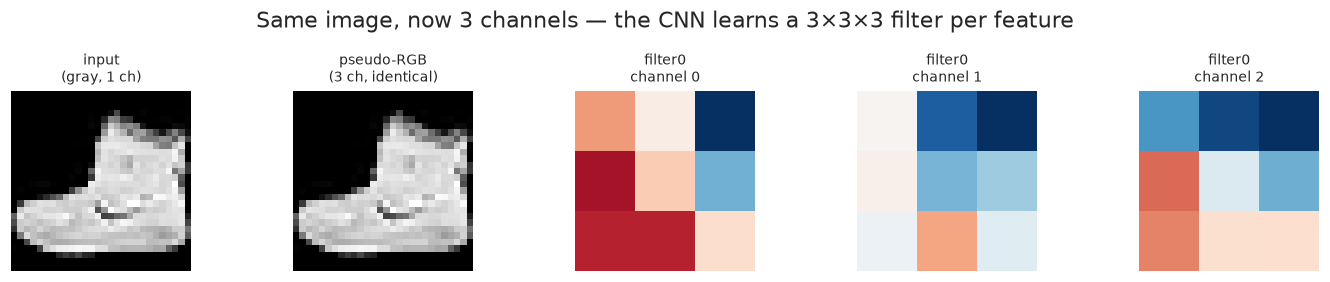

In [17]:
# Show the grayscale image next to its 3-channel version and the first conv filters.
w1 = cnn_rgb.get_layer("conv1_rgb").get_weights()[0]
fig, axes = plt.subplots(1, 5, figsize=(13, 2.6))
axes[0].imshow(x_train[0], cmap="gray"); axes[0].set_title("input\n(gray, 1 ch)", fontsize=9)
axes[1].imshow(x_rgb[0]); axes[1].set_title("pseudo-RGB\n(3 ch, identical)", fontsize=9)
for k in range(3):
 # filter 0 across the 3 input channels: how it weights R vs G vs B
 axes[2+k].imshow(w1[:, :, :, 0][:, :, k], cmap="RdBu_r",
 vmin=-w1.max(), vmax=w1.max())
 axes[2+k].set_title(f"filter0\nchannel {k}", fontsize=9)
for ax in axes: ax.axis("off")
plt.suptitle("Same image, now 3 channels — the CNN learns a 3×3×3 filter per feature")
plt.tight_layout(); plt.show()

The CNN trains identically and reaches the same accuracy as the grayscale version —
confirming that moving from 1 to 3 channels is just a shape change in the first
filter bank. For *real* colour images the three channels carry different
information (R≠G≠B), which is exactly what lets the first-layer filters learn
colour-sensitive features (e.g. "greenish patches = foliage"). The architecture
doesn't care; it just gets a deeper input.

> **Where the real colour work lives.** Datasets like **CIFAR-10** (`32×32` colour)
> and **ImageNet** (`224×224` colour) are the standard benchmarks for colour CNNs.
> CIFAR is harder than Fashion-MNIST — same architecture, lower accuracy, because
> `32×32` colour objects (cat vs dog, deer vs horse) are genuinely more variable
> than `28×28` grayscale garments. Real gains there need depth, augmentation, and
> ultimately a pre-trained backbone (§8). We skip the CIFAR download here to keep
> the notebook self-contained; try it yourself with `keras.datasets.cifar10.load_data()`.

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Forgetting the channel axis (§4).** Keras CNNs want `(H, W, C)`. Grayscale
 images load as `(H, W)` — you must add the channel dim with `X[..., None]` or the
 `Input(shape=(28,28,1))` will reject them. The error message is cryptic; this is
 the fix.
2. **Comparing CNN to MLP at equal parameter count (§5).** That's the *wrong*
 comparison. The point is the CNN wins *with fewer* parameters. Equal-params
 comparisons flatter the MLP and hide the real lesson (parameter sharing).
3. **Reading only test accuracy (§4, §6).** The train/val *gap* is the diagnostic.
 A model at `0.99` train / `0.91` val is overfitting harder than one at `0.92` /
 `0.90` — and the second will deploy better. Always plot both curves.
4. **Too big a model, too little data (§6).** A 128-filter CNN on 60 images is a
 recipe for memorisation. Reach for augmentation and dropout *before* reaching for
 capacity.
5. **Not scaling pixel values to [0,1] (§4).** Same lesson as notebook 09 §6 and
 notebook 14 §5 — unscaled inputs make the loss surface ill-conditioned. Divide by 255.
6. **Training from scratch when a pre-trained backbone exists (§8).** For natural
 images you almost always want transfer learning. Train-from-scratch is for
 learning, or for image types utterly unlike ImageNet (medical, satellite).
7. **Ignoring stride/padding until the spatial dims collapse to 0.** If your conv
 output shrinks faster than you pooled, `Flatten` produces a tiny vector and
 accuracy tanks silently. Keep an eye on the shapes in `model.summary()`.

## Exercises

1. **(§4)** Double the number of filters in each conv layer (8→16, 16→32). Does
 Fashion-MNIST validation accuracy improve enough to justify the extra params?
 What does that tell you about the dataset's complexity?
2. **(§5)** The MLP used a `128→64` dense stack. Try an MLP with *more* parameters
 than the CNN (e.g. `512→256`). Does it ever beat the CNN? Why not?
3. **(§6)** Remove the augmentation but keep dropout, then remove dropout but keep
 augmentation. Which single regulariser helps more on Fashion-MNIST?
4. **(§7)** Take an image the CNN misclassifies (find one in the test set) and pass
 it through the feature-map visualiser. Can you tell, by eye, *why* it failed?
5. **(§8)** Freeze the whole MobileNetV2 backbone and train only the head for 5
 epochs on a small CIFAR-10 subset. Compare to training the from-scratch CNN of §9.
 Which wins, and by how much?

<details><summary>Answers (click to expand)</summary>

```python
# 1: ~91% -> ~92% val acc, a small bump for roughly 4x params. Fashion-MNIST is
# simple enough that 8/16 filters capture most structure; past that you pay for
# capacity you can't exploit without more data. Diminishing returns.
# 2: Bigger MLPs get within ~1-2% of the small CNN at best, with 5-10x more
# params, and overfit faster. The CNN's win is architectural (parameter sharing
# + locality), not from having more raw capacity.
# 3: Augmentation usually helps more on Fashion-MNIST (it directly combats the
# "object must be centred" failure). Dropout helps the dense head but the conv
# layers are already fairly regularised by pooling. Combining both is best.
# 4: Often the failure is a visually ambiguous case (a coat that looks like a
# pullover); the conv2 maps lack a strong part-response -> the dense layer
# gets a muddled code. Occasionally it's a true mislabel.
# 5: Transfer learning wins comfortably (often +5-10% on a 10k-image CIFAR
# subset). The pre-trained features are the whole point: you sidestep the
# small-data problem entirely.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §6 (bias–variance
 & overfitting), §9 (receptive field, parameter sharing, skip connections).
- **Notebook 09** — the MLP you're building on; this notebook's §5 is the contrast.
- **Notebook 14** — gradient descent & backprop math; the conv layer is just a
 specialised linear layer whose backprop is the same chain rule.
- **Notebook 15** — ReLU, dropout, optimisers used here without re-derivation.
- Lectures 5–9 (CNN motivation, a simple CNN, CNN internals, modern
 architectures, transfer learning) — this notebook covers that arc.
- LeCun et al. (1998), *Gradient-Based Learning Applied to Document Recognition*
 (LeNet). He et al. (2015), *Deep Residual Learning* (ResNet).
- Keras 3 docs: <https://keras.io/> · TF transfer learning guide:
 <https://www.tensorflow.org/tutorials/images/transfer_learning>